ADTA5560 Recurrent Neural Network: Final Project
Simple RNN with Sine Wave Data 
Build, Train, and Test a Simple RNN on Sine Wave Data 
Follow the steps discussed in the lectures (PDFs and videos) and redo the lecture project of building, training, and testing a simple recurrent neural network on sine wave data using TensorFlow (backend) and Keras

##  Importing Libraries

In [38]:
# import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [39]:
# for timeseries RNN neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [40]:
# import keras: TimeseriesGenerator
# this class produces time series batches used on training/testing the model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# import keras: MinMax scalar
# this class is used to preprocess (scale) the data
from sklearn.preprocessing import MinMaxScaler

# Generate Data 

In [41]:
# create a simple sine wave in numpy

x = np.linspace(0,60,1080)
y = np.sin(x)


In [42]:
x

array([0.00000000e+00, 5.56070436e-02, 1.11214087e-01, ...,
       5.98887859e+01, 5.99443930e+01, 6.00000000e+01])

In [43]:
y

array([ 0.        ,  0.05557839,  0.11098497, ..., -0.197224  ,
       -0.2514059 , -0.30481062])

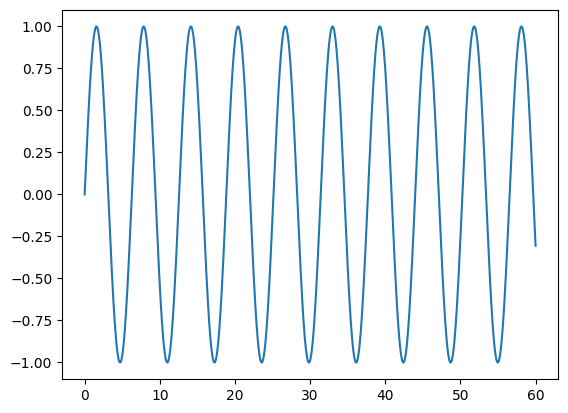

In [44]:
plt.plot(x, y)

In [45]:
# load data into a dataframe

df= pd.DataFrame(data=y, index=x, columns=['Sine'])
df.head(5)

,Sine
0.000000,0.000000
0.055607,0.055578
0.111214,0.110985
0.166821,0.166048
0.222428,0.220599


In [46]:
len(df)

1080

# Split train and test data

In [47]:
# set percentage of data used for testing

test_percent=0.2

In [48]:
# Number of data points reserved for tesing the model
# 20% of the original dataset

len(df)*test_percent

216.0

In [49]:
# need to find the length (number of data points) of the testing dataset
# It has been found (above) that around 205 data points are used for testing 

test_length = np.round(len(df)*test_percent)
test_length 

216.0

In [50]:
# The testing dataset  starts at this index
# Index starting with 0

test_start_index = int(len(df) - test_length)

In [51]:
test_start_index

864

In [52]:
# Create separate training / testing datasets

# Training dataset: All the indices from start to the test_start_index 
# ( excluding the test_start_index)

data_train = df.iloc[: test_start_index]

# Testing dataset: all the indices from the test_start_index to the end of the dataframe
# (including test_start_index)

data_test= df.iloc[test_start_index :]

data_train.head(5)


,Sine
0.000000,0.000000
0.055607,0.055578
0.111214,0.110985
0.166821,0.166048
0.222428,0.220599


In [53]:
data_test.head(5)


,Sine
48.044486,-0.795962
48.100093,-0.828376
48.155700,-0.858229
48.211307,-0.885429
48.266914,-0.909892


## Normalize the data ( scale it into [0,1])

In [54]:
# Create a MinMaxScalar to normalize the data
scalar = MinMaxScaler()

In [ ]:
# IGNORE the warning: Just converting the data to floats
# Only Scale the Trainig data  - Not scale the testing data
# train the scalar to perform the normalization

scalar.fit(data_train)

MinMaxScaler()

In [56]:
# Normalize the training dataset
normalized_train= scalar.transform(data_train)

# Normalize the testing dataset
normalized_train= scalar.transform(data_test)

# Create timeseries generator instance

In [57]:
#from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Set the length of the input sequence
# i.e., the number of time series steps used to predict the next one
# Use 50 historical data points to predict the next one
length = 40

# Set the batch size
# Number of time series samples in each batch
# Only one sample in each batch
batch_size = 1

# Create a TimeSeriesGenerator for training
# This time series generator produces time series batches used to train the model
# TimeseriesGenerator(inputs dataset, outputs dataset, length, batch_size)
train_tsGenerator40 = TimeseriesGenerator(normalized_train, normalized_train, length=length, batch_size=batch_size)

# Get the length of the normalized training data
len(normalized_train)


216

In [58]:
# first batch
X,y=train_tsGenerator40[0]


In [59]:
X.flatten()

array([1.01976490e-01, 8.57682584e-02, 7.08405292e-02, 5.72394488e-02,
       4.50070628e-02, 3.41811857e-02, 2.47952842e-02, 1.68783732e-02,
       1.04549268e-02, 5.54480189e-03, 2.16317750e-03, 3.20507364e-04,
       2.24878241e-05, 1.27004016e-03, 4.05930775e-03, 8.38166801e-03,
       1.42237590e-02, 2.15675208e-02, 3.03902514e-02, 4.06646765e-02,
       5.23590344e-02, 6.54371738e-02, 7.98586656e-02, 9.55789280e-02,
       1.12549364e-01, 1.30717513e-01, 1.50027209e-01, 1.70418761e-01,
       1.91829131e-01, 2.14192132e-01, 2.37438633e-01, 2.61496769e-01,
       2.86292170e-01, 3.11748184e-01, 3.37786117e-01, 3.64325478e-01,
       3.91284224e-01, 4.18579017e-01, 4.46125478e-01, 4.73838451e-01])

In [60]:
y

array([[0.50163227]])

## Build Train and Test Model

# Build simple RNN Model

In [61]:
# Data set: Only one column/attribute: Sine values of index x
# Features: How many features used to train the model: Only one
n_features = 1

# define model
model = Sequential()

# Add a simple RNN layer: Using SimpleRNN cells
# This layer has 100 neurons: One neuron for each input data point
# NOTES: # time series steps of the input sequence: 50
model.add(SimpleRNN(100, input_shape=(length, n_features)))

# Add a FC (fully-connected) layer for the final prediction
# Only one neuron of the Dense/Fully-Connected layer
# --> Output: Predict the next data point of the input sequence: only one value
model.add(Dense(1))


/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# complie model

In [62]:
# complie the model

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,301 (40.24 KB)

 Trainable params: 10,301 (40.24 KB)

 Non-trainable params: 0 (0.00 B)

# Train (Fit) Model

In [63]:
# Fit the model
# Use fit_generator(), Not fit()

#model.fit_generator(train_tsGenerator40, epochs=5)
model.fit(train_tsGenerator40,epochs=5 )


Epoch 1/5
 28/176 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2958

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0816
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7115e-04
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8662e-04
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.4739e-04
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5065e-04


# Visualize Model's Porformance After Training  

<Axes: >

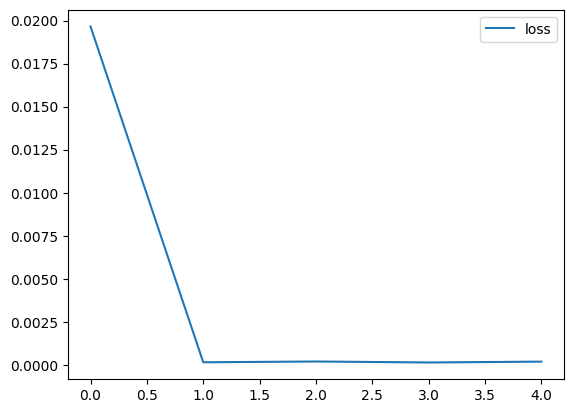

In [64]:
# load the loss data into a dataframe

df_model_loss = pd.DataFrame(model.history.history)

# visualize the loss data using Dataframe.plot()
df_model_loss.plot()


# Evaluate Model on Test Data

# A sneakpeak into the test data

In [65]:
length

40

In [66]:
first_eval_batch = normalized_train[-length : ]
first_eval_batch


array([[0.9794154 ],
       [0.98657181],
       [0.99222402],
       [0.99635456],
       [0.99895067],
       [1.00000432],
       [0.99951225],
       [0.99747598],
       [0.99390181],
       [0.98880078],
       [0.98218867],
       [0.97408592],
       [0.96451757],
       [0.9535132 ],
       [0.94110684],
       [0.92733683],
       [0.91224574],
       [0.89588022],
       [0.87829087],
       [0.85953206],
       [0.83966178],
       [0.81874146],
       [0.79683576],
       [0.77401241],
       [0.75034196],
       [0.72589759],
       [0.70075485],
       [0.67499148],
       [0.64868712],
       [0.62192308],
       [0.59478211],
       [0.5673481 ],
       [0.53970586],
       [0.51194084],
       [0.48413888],
       [0.45638592],
       [0.42876775],
       [0.40136976],
       [0.37427663],
       [0.34757213]])

In [67]:
first_eval_batch=first_eval_batch.reshape((1,length,n_features))

first_eval_batch

array([[[0.9794154 ],
        [0.98657181],
        [0.99222402],
        [0.99635456],
        [0.99895067],
        [1.00000432],
        [0.99951225],
        [0.99747598],
        [0.99390181],
        [0.98880078],
        [0.98218867],
        [0.97408592],
        [0.96451757],
        [0.9535132 ],
        [0.94110684],
        [0.92733683],
        [0.91224574],
        [0.89588022],
        [0.87829087],
        [0.85953206],
        [0.83966178],
        [0.81874146],
        [0.79683576],
        [0.77401241],
        [0.75034196],
        [0.72589759],
        [0.70075485],
        [0.67499148],
        [0.64868712],
        [0.62192308],
        [0.59478211],
        [0.5673481 ],
        [0.53970586],
        [0.51194084],
        [0.48413888],
        [0.45638592],
        [0.42876775],
        [0.40136976],
        [0.37427663],
        [0.34757213]]])

In [68]:
first_eval_batch.shape


(1, 40, 1)

# Evaluate Model

In [69]:
# ALL the code for evaluation

# Declare a list to store all the predictions
# Similar to: test_predictions = list()
test_predictions = []

# Get the first time series batch for testing
# The 1st batch: The 1st time series input sequence
# = The last 50 data points of the train data set
first_eval_batch = normalized_train[-length:]

# Reshape the batch into 3D array: #samples/batch x Length x #features
current_batch = first_eval_batch.reshape((1, length, n_features))

# Run a FOR loop to make a prediction for each batch
for i in range(len(data_test)):

    # Get the value of the first element: The prediction
    current_pred = model.predict(current_batch)[0]

    # Store prediction into the list of predictions
    test_predictions.append(current_pred)

    # Generate a new batch to prepare for the next iteration of testing
    # --> Drop the first data point of the current input sequence
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

In [70]:
# convert the scaled result back to the real values
true_predictions= scalar.inverse_transform(test_predictions)

true_predictions

array([[-3.37393940e-01],
       [-3.83824017e-01],
       [-4.21757002e-01],
       [-4.63737712e-01],
       [-4.95868054e-01],
       [-5.28684004e-01],
       [-5.50755023e-01],
       [-5.69954224e-01],
       [-5.85853737e-01],
       [-5.96926258e-01],
       [-6.03106227e-01],
       [-6.04708718e-01],
       [-6.01441454e-01],
       [-5.90421321e-01],
       [-5.74550892e-01],
       [-5.53818128e-01],
       [-5.31555794e-01],
       [-5.00070411e-01],
       [-4.68370587e-01],
       [-4.28739126e-01],
       [-3.88094347e-01],
       [-3.41346484e-01],
       [-2.91048376e-01],
       [-2.40423482e-01],
       [-1.85779591e-01],
       [-1.34911053e-01],
       [-7.33847491e-02],
       [-1.67054038e-02],
       [ 4.54445529e-02],
       [ 1.00300977e-01],
       [ 1.58983593e-01],
       [ 2.11600016e-01],
       [ 2.64877163e-01],
       [ 3.15580550e-01],
       [ 3.65813455e-01],
       [ 4.15544411e-01],
       [ 4.56158019e-01],
       [ 4.96246790e-01],
       [ 5.2

In [71]:
data_test

,Sine
48.044486,-0.795962
48.100093,-0.828376
48.155700,-0.858229
48.211307,-0.885429
48.266914,-0.909892
...,...
59.777572,-0.087201
59.833179,-0.142432
59.888786,-0.197224
59.944393,-0.251406


In [72]:
# Copy the true values of predictions into the dataframe of original test data
# Add it as another column

data_test['Predictions'] = true_predictions

/var/tmp/ipykernel_6883/1664254025.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test['Predictions'] = true_predictions


In [73]:
data_test

,Sine,Predictions
48.044486,-0.795962,-0.337394
48.100093,-0.828376,-0.383824
48.155700,-0.858229,-0.421757
48.211307,-0.885429,-0.463738
48.266914,-0.909892,-0.495868
...,...,...
59.777572,-0.087201,0.170804
59.833179,-0.142432,0.197205
59.888786,-0.197224,0.195787
59.944393,-0.251406,0.217246


<Axes: >

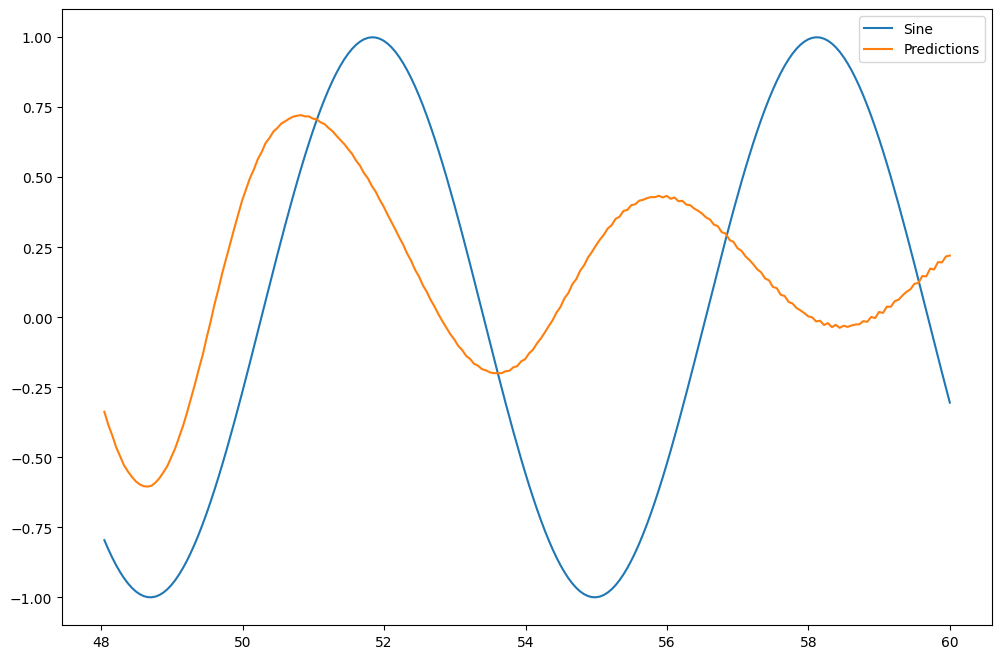

In [74]:
# visualize the updated data set
# Compare the predicted sine wave against the original sine wave

data_test.plot(figsize=(12,8))
